## Defensive recomputation

The denoising control interval is recomputed from the run configuration and mapped in reverse to inversion indices. The notebook then checks that every mapped step is present before aggregating masks.

# Inversion-Stage Localization

This notebook isolates one question: **can a target prompt evaluated on source inversion states produce a useful spatial localization signal?** It studies only the inversion trajectory, its per-step signals, and the feasibility of extracting a mask. No forward FYS mask, edited image, or ground-truth mask is used to construct a signal.

## 1. Frozen setup

The probe uses the 12-case manifest and the existing `seed=0` outputs. Every recorded inversion step is inspected. This notebook deliberately does not select a FYS denoising interval and does not compare against forward FYS; that comparison belongs to Notebook 07.

In [5]:
from pathlib import Path
import json, math
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pyproject.toml").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not find repository root")
    REPO_ROOT = REPO_ROOT.parent

MANIFEST_PATH = REPO_ROOT / "core/data/partedit_subset/pilot_12_manifest.json"
PROBE_ROOT = REPO_ROOT / "core/results/same_state_inversion_probe"
manifest = json.loads(MANIFEST_PATH.read_text())

SMOOTHING_SIGMA = 0.7
SOFTMAX_SCALE = 5.0

print("cases:", len(manifest))
print("inversion analysis: all recorded inversion steps per case")
print("forward masks and FYS denoising intervals are intentionally excluded")

cases: 12
inversion analysis: all recorded inversion steps per case
forward masks and FYS denoising intervals are intentionally excluded


## 2. Signal definitions

For each inversion state:

- `part attention`: attention mass from image-token queries to the target part token(s).
- `part+edit attention`: the combined attention mass for the part and edit token groups.
- `gate attention`: strict pointwise product `part attention × delta-v`.

For each signal, maps are normalized per step and aggregated across all recorded inversion steps with the same temporal softmax construction used by FYS. This all-step aggregation is an inversion-only diagnostic, not the timestep-matched comparison used in Notebook 07. The product gate is included as a diagnostic only; velocity modulation is intentionally not included in this formal result.

In [6]:
def load_map(path):
    value = np.asarray(np.load(path), dtype=np.float32).squeeze()
    if value.ndim != 2 or not np.isfinite(value).all():
        raise ValueError(f"Invalid map: {path} -> {value.shape}")
    return value

def normalize01(value):
    value = np.asarray(value, dtype=np.float32)
    lo, hi = float(value.min()), float(value.max())
    return (value - lo) / (hi - lo) if hi > lo else np.zeros_like(value)

def otsu_threshold(value):
    value = np.asarray(value, dtype=np.float32)
    hist, edges = np.histogram(value.ravel(), bins=256)
    centers = (edges[:-1] + edges[1:]) / 2
    wb = np.cumsum(hist); wf = hist.sum() - wb
    valid = (wb > 0) & (wf > 0)
    mb = np.cumsum(hist * centers) / np.maximum(wb, 1e-12)
    mf = (np.cumsum((hist * centers)[::-1]) / np.maximum(np.cumsum(hist[::-1]), 1e-12))[::-1]
    between = wb * wf * (mb - mf) ** 2
    between[~valid] = -1
    return float(centers[np.argmax(between)])

def reverse_step_indices(denoising_steps, num_steps):
    \"\"Map denoising indices to the corresponding reversed inversion indices.\"\"\"
    return [int(num_steps - 1 - step) for step in denoising_steps]

def resize_gt(path, shape):
    return np.asarray(Image.open(path).convert("L").resize((shape[1], shape[0]), Image.Resampling.NEAREST)) > 0

def fys_aggregate(step_maps, scale=SOFTMAX_SCALE):
    """Match FYS temporal aggregation: per-step normalization, spatial softmax over steps, weighted sum."""
    normalized = np.stack([normalize01(x) for x in step_maps], axis=0)
    weights = np.exp(scale * normalized - np.max(scale * normalized, axis=0, keepdims=True))
    weights /= np.maximum(weights.sum(axis=0, keepdims=True), 1e-12)
    soft = (normalized * weights).sum(axis=0)
    smoothed = gaussian_filter(soft, sigma=SMOOTHING_SIGMA)
    binary = smoothed > otsu_threshold(smoothed)
    return soft.astype(np.float32), smoothed.astype(np.float32), binary.astype(np.uint8)

def average_precision(score, gt):
    order = np.argsort(-score.ravel(), kind="stable")
    labels = gt.ravel()[order]
    tp = np.cumsum(labels)
    precision = tp / (np.arange(labels.size) + 1)
    return float((precision * labels).sum() / max(int(gt.sum()), 1))

def metric_row(case_uid, part_size, part, edit, method, score, binary, gt):
    score = normalize01(score); binary = np.asarray(binary).astype(bool); gt = np.asarray(gt).astype(bool)
    union = np.logical_or(binary, gt).sum()
    return {"case_uid":case_uid,"part_size":part_size,"part":part,"edit":edit,"method":method,
            "gt_area":float(gt.mean()),"pred_area":float(binary.mean()),
            "area_ratio":float(binary.mean()/gt.mean()),
            "iou":float(np.logical_and(binary,gt).sum()/union) if union else np.nan,
            "soft_ap":average_precision(score,gt),
            "inside_mass":float(score[gt].sum()/max(score.sum(),1e-12)),
            "outside_mass":float(score[~gt].sum()/max(score.sum(),1e-12))}

## 3. Per-step inversion signals

In [7]:
def probe_dir(uid):
    path = PROBE_ROOT / uid / "seed_000"
    if not (path / "probe_metadata.json").exists():
        raise FileNotFoundError(path)
    return path

per_step_rows=[]
aggregate_rows=[]
cache={}
for record in manifest:
    uid=record["case_uid"]; rd=probe_dir(uid)
    meta=json.loads((rd/"probe_metadata.json").read_text())
    steps=[int(x) for x in meta["recorded_step_indices"]]
    signals={"part_attention":[],"part_edit_attention":[],"gate_attention":[]}
    for step in steps:
        v=normalize01(load_map(rd/"steps"/f"step_{step:02d}_velocity_delta.npy"))
        p=normalize01(load_map(rd/"steps"/f"step_{step:02d}_part_attention.npy"))
        e=normalize01(load_map(rd/"steps"/f"step_{step:02d}_edit_attention.npy"))
        signals["part_attention"].append(p)
        signals["part_edit_attention"].append(normalize01(p+e))
        signals["gate_attention"].append(normalize01(p*v))
    shape=signals["part_attention"][0].shape
    gt=resize_gt(REPO_ROOT/record["gt_mask"],shape)
    cache[uid]={"record":record,"gt":gt,"steps":steps,"signals":signals}
    for name, maps in signals.items():
        for step, score in zip(steps,maps):
            smooth=gaussian_filter(score,sigma=SMOOTHING_SIGMA)
            binary=smooth>otsu_threshold(smooth)
            row = metric_row(uid,record["part_size"],record["part"],record["edit"],name, smooth,binary,gt)
            row["step"] = step
            per_step_rows.append(row)
        selected=[maps[steps.index(s)] for s in steps]
        soft,smooth,binary=fys_aggregate(selected)
        aggregate_rows.append(metric_row(uid,record["part_size"],record["part"],record["edit"],name+"_all_inversion",smooth,binary,gt))

per_step_metrics=pd.DataFrame(per_step_rows)
aggregate_metrics=pd.DataFrame(aggregate_rows)
OUT_ROOT=REPO_ROOT/"core/results/inversion_localization_eval"
OUT_ROOT.mkdir(parents=True,exist_ok=True)
per_step_metrics.to_csv(OUT_ROOT/"per_step_metrics.csv",index=False)
aggregate_metrics.to_csv(OUT_ROOT/"aggregate_metrics.csv",index=False)
summary=aggregate_metrics.groupby("method",as_index=False).agg(cases=("case_uid","nunique"),mean_iou=("iou","mean"),mean_soft_ap=("soft_ap","mean"),mean_area_ratio=("area_ratio","mean"),mean_inside_mass=("inside_mass","mean"),mean_outside_mass=("outside_mass","mean"))
summary.to_csv(OUT_ROOT/"summary.csv",index=False)
display(summary.round(4))


,method,cases,mean_iou,mean_soft_ap,mean_area_ratio,mean_inside_mass,mean_outside_mass
0,gate_attention_all_inversion,12,0.4024,0.6919,3.2782,0.3180,0.6820
1,part_attention_all_inversion,12,0.3406,0.7068,3.9529,0.2496,0.7504
2,part_edit_attention_all_inversion,12,0.3072,0.7227,5.0219,0.2096,0.7904


## 4. Inversion mask visualization

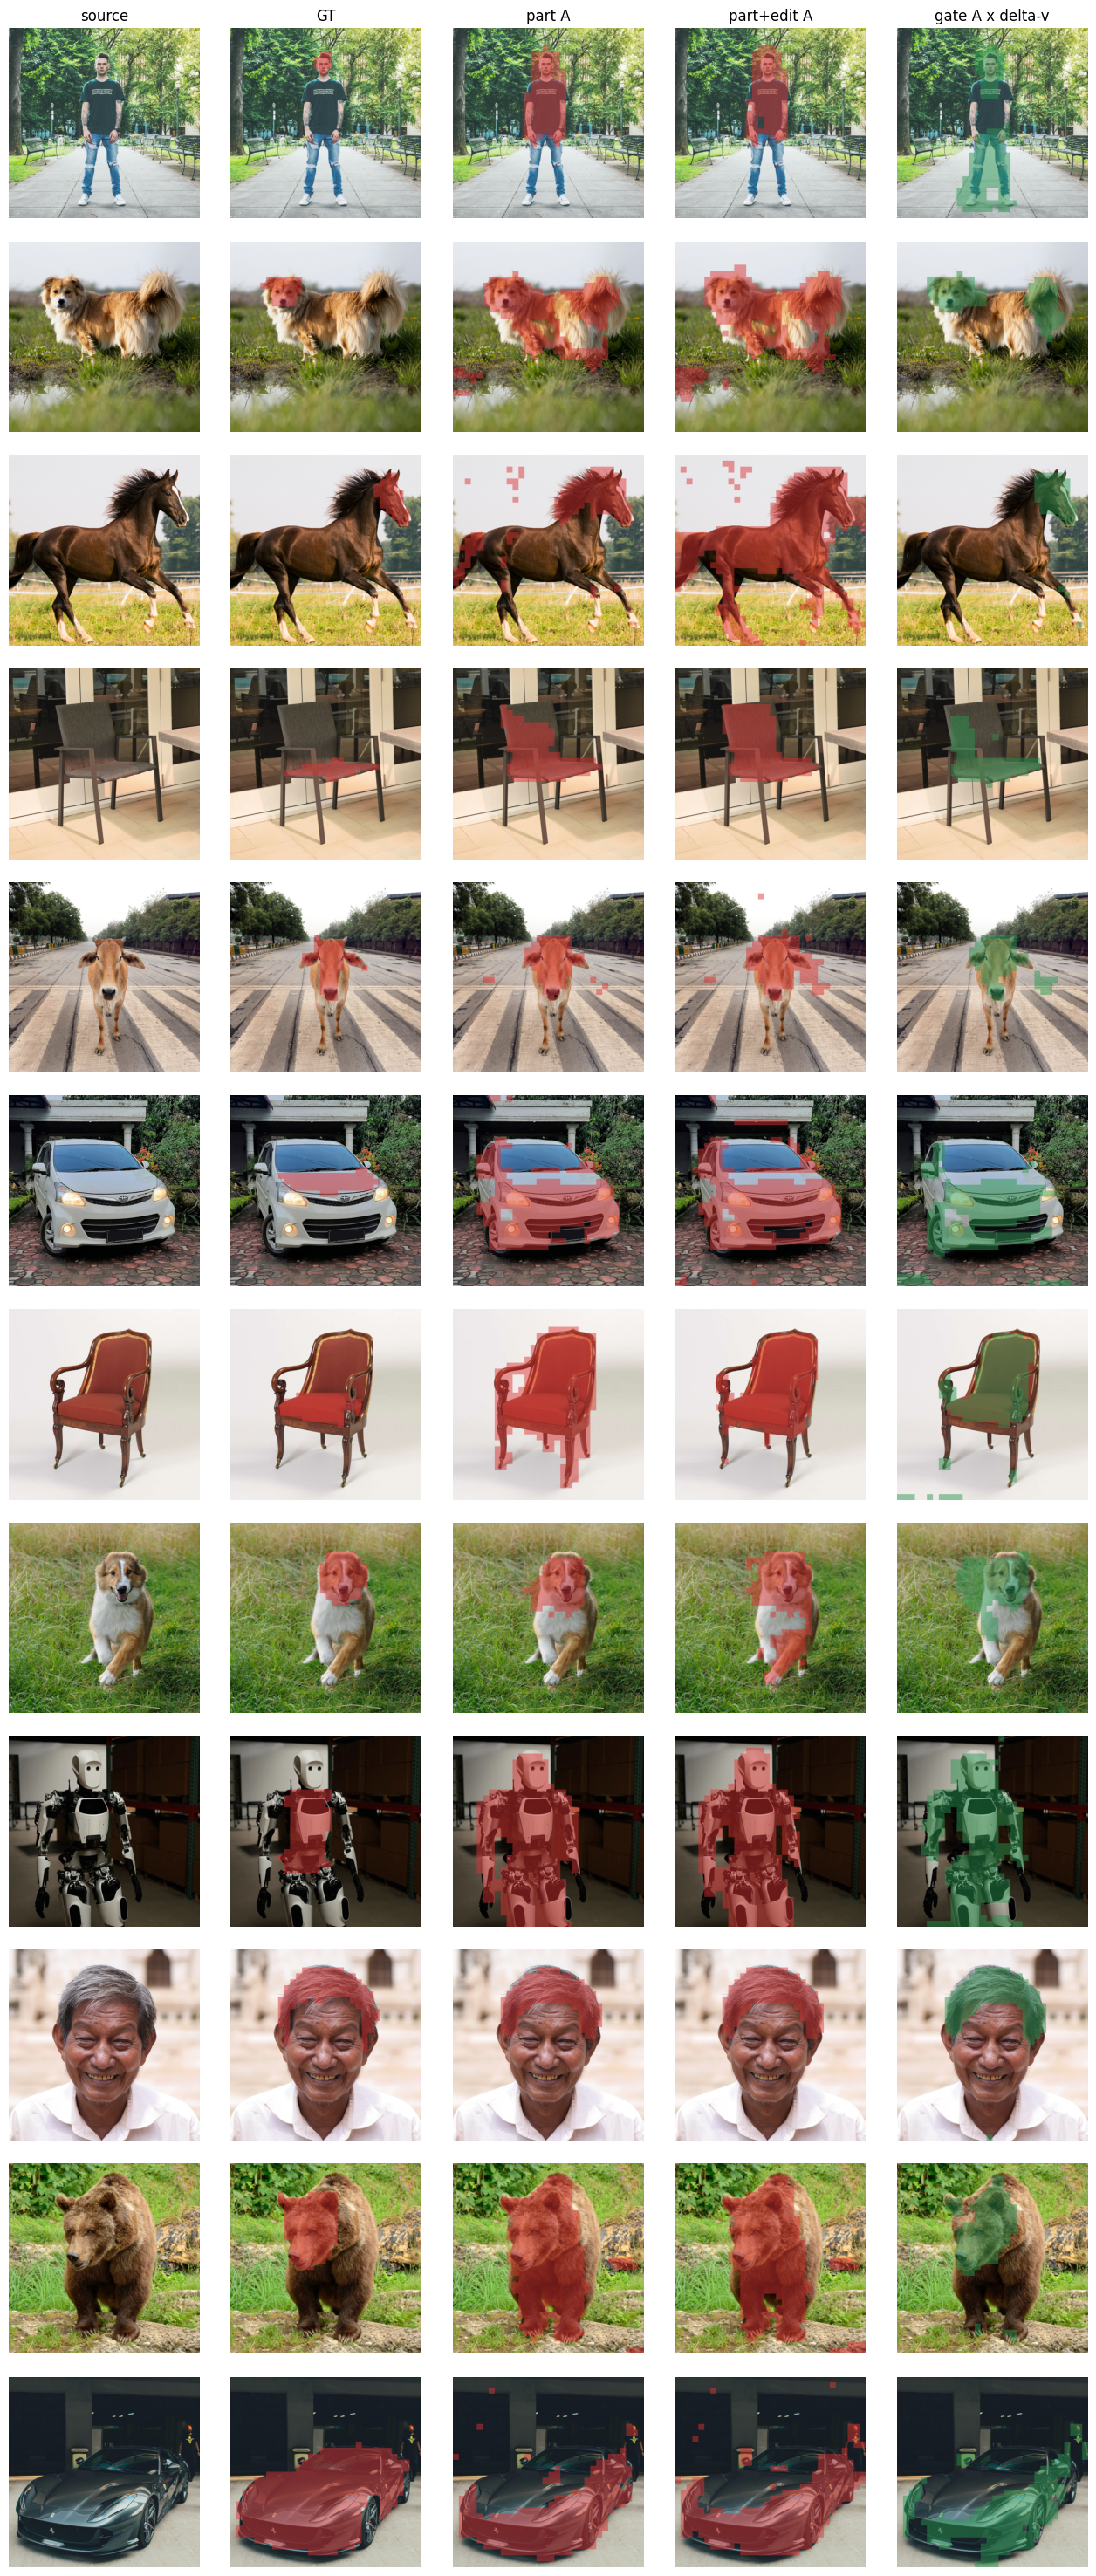

saved: /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/inversion_localization_eval/inversion_mask_overlays_seed0.png


In [8]:
def overlay(source_path,mask,color=(220,50,50),alpha=.48):
    base=np.asarray(Image.open(source_path).convert("RGB").resize((384,384)))/255.
    m=np.asarray(Image.fromarray((np.asarray(mask,dtype=np.uint8)*255)).resize((384,384),Image.Resampling.NEAREST))>0
    tint=np.empty_like(base); tint[:]=np.asarray(color)/255.
    return np.where(m[...,None],base*(1-alpha)+tint*alpha,base)

fig,axes=plt.subplots(len(manifest),5,figsize=(15,2.5*len(manifest)),squeeze=False)
labels=["source","GT","part A","part+edit A","gate A x delta-v"]
for j,label in enumerate(labels): axes[0,j].set_title(label)
for i,record in enumerate(manifest):
    item=cache[record["case_uid"]]; rd=probe_dir(record["case_uid"]); steps=item["steps"]
    maps={k:fys_aggregate(v)[2] for k,v in {
        "part_attention":[item["signals"]["part_attention"][steps.index(s)] for s in steps],
        "part_edit_attention":[item["signals"]["part_edit_attention"][steps.index(s)] for s in steps],
        "gate_attention":[item["signals"]["gate_attention"][steps.index(s)] for s in steps],
    }.items()}
    source=REPO_ROOT/record["source_image"]
    axes[i,0].imshow(Image.open(source).convert("RGB")); axes[i,0].axis("off")
    axes[i,0].set_ylabel(f'{record["case_uid"]}\n{record["part"]} -> {record["edit"]}',rotation=0,ha="right",va="center",fontsize=8,labelpad=34)
    axes[i,1].imshow(overlay(source,item["gt"])); axes[i,1].axis("off")
    for j,key,color in [(2,"part_attention",(220,50,50)),(3,"part_edit_attention",(220,50,50)),(4,"gate_attention",(40,150,80))]:
        axes[i,j].imshow(overlay(source,maps[key],color)); axes[i,j].axis("off")
fig.subplots_adjust(left=.15,right=.995,top=.98,bottom=.01,wspace=.02,hspace=.12)
fig_path=OUT_ROOT/"inversion_mask_overlays_seed0.png"; fig.savefig(fig_path,dpi=160,bbox_inches="tight",facecolor="white"); plt.show(); print("saved:",fig_path)

## 5. Conclusion

If the inversion-derived signals show higher IoU/AP, lower area inflation, and more mass inside the GT region than a non-informative baseline, the result supports the limited claim that source inversion states contain usable target-prompt localization information. This notebook does not test denoising control or final image quality; those questions belong to the next experiment.

## 5. Stepwise quality and stability

The following views check whether inversion localization is present across steps rather than only in the aggregate. Cases are selected deterministically from the `gate_attention` aggregate IoU: the closest-to-median case, the highest-IoU case, and the lowest-IoU case. The curves below still use all 12 cases.

In [9]:
# Select representative cases without manual cherry-picking.
gate_rows = aggregate_metrics[aggregate_metrics["method"] == "gate_attention_all_inversion"].copy()
gate_rows = gate_rows.sort_values(["iou", "case_uid"]).reset_index(drop=True)
median_iou = float(gate_rows["iou"].median())
median_case = gate_rows.iloc[(gate_rows["iou"] - median_iou).abs().argsort().iloc[0]]["case_uid"]
representative_uids = [
    gate_rows.iloc[0]["case_uid"],
    median_case,
    gate_rows.iloc[-1]["case_uid"],
]
representative_labels = {
    representative_uids[0]: "lower-IoU case",
    representative_uids[1]: "median-IoU case",
    representative_uids[2]: "higher-IoU case",
}
print("representative cases:", [(uid, representative_labels[uid]) for uid in representative_uids])

# Add temporal stability features to the per-step table.
stability_rows = []
for uid, item in cache.items():
    for signal_name, maps in item["signals"].items():
        binary_maps = []
        for score in maps:
            smooth = gaussian_filter(normalize01(score), sigma=SMOOTHING_SIGMA)
            binary_maps.append((smooth > otsu_threshold(smooth)).astype(bool))
        for index, (step, binary) in enumerate(zip(item["steps"], binary_maps)):
            previous_iou = np.nan
            aggregate_iou = np.nan
            if index:
                prev = binary_maps[index - 1]
                previous_iou = float(np.logical_and(binary, prev).sum() / max(np.logical_or(binary, prev).sum(), 1))
            stability_rows.append({
                "case_uid": uid,
                "method": signal_name,
                "step": step,
                "adjacent_mask_iou": previous_iou,
                "binary_area_ratio": float(binary.mean() / max(item["gt"].mean(), 1e-12)),
            })
stability_metrics = pd.DataFrame(stability_rows)
stability_metrics.to_csv(OUT_ROOT / "stability_metrics.csv", index=False)
display(stability_metrics.groupby("method", as_index=False).agg(
    cases=("case_uid", "nunique"),
    mean_adjacent_mask_iou=("adjacent_mask_iou", "mean"),
    area_ratio_std=("binary_area_ratio", "std"),
).round(4))


representative cases: [('real_0006', 'lower-IoU case'), ('real_0009', 'median-IoU case'), ('real_0011', 'higher-IoU case')]


,method,cases,mean_adjacent_mask_iou,area_ratio_std
0,gate_attention,12,0.5977,2.1962
1,part_attention,12,0.6991,3.4111
2,part_edit_attention,12,0.7495,4.0870


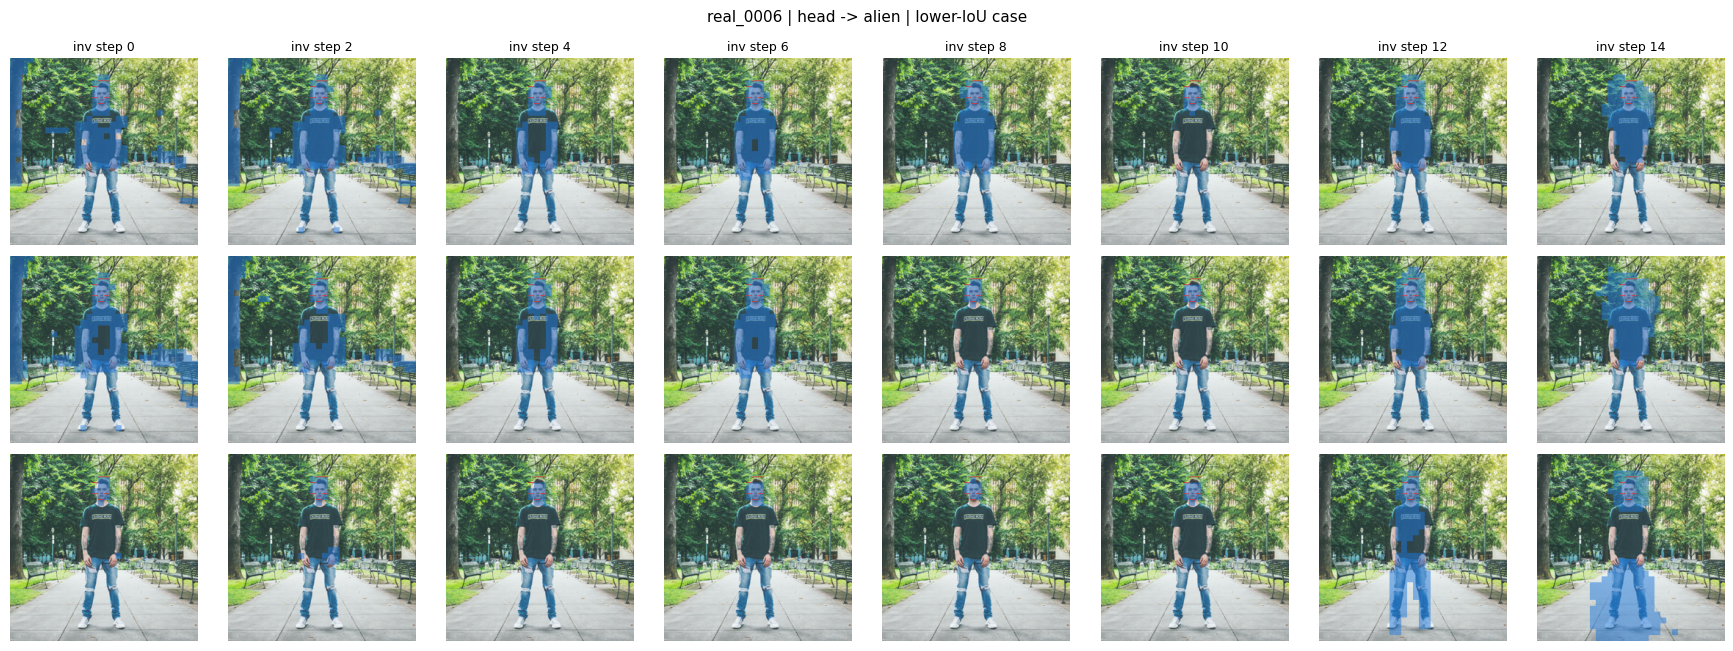

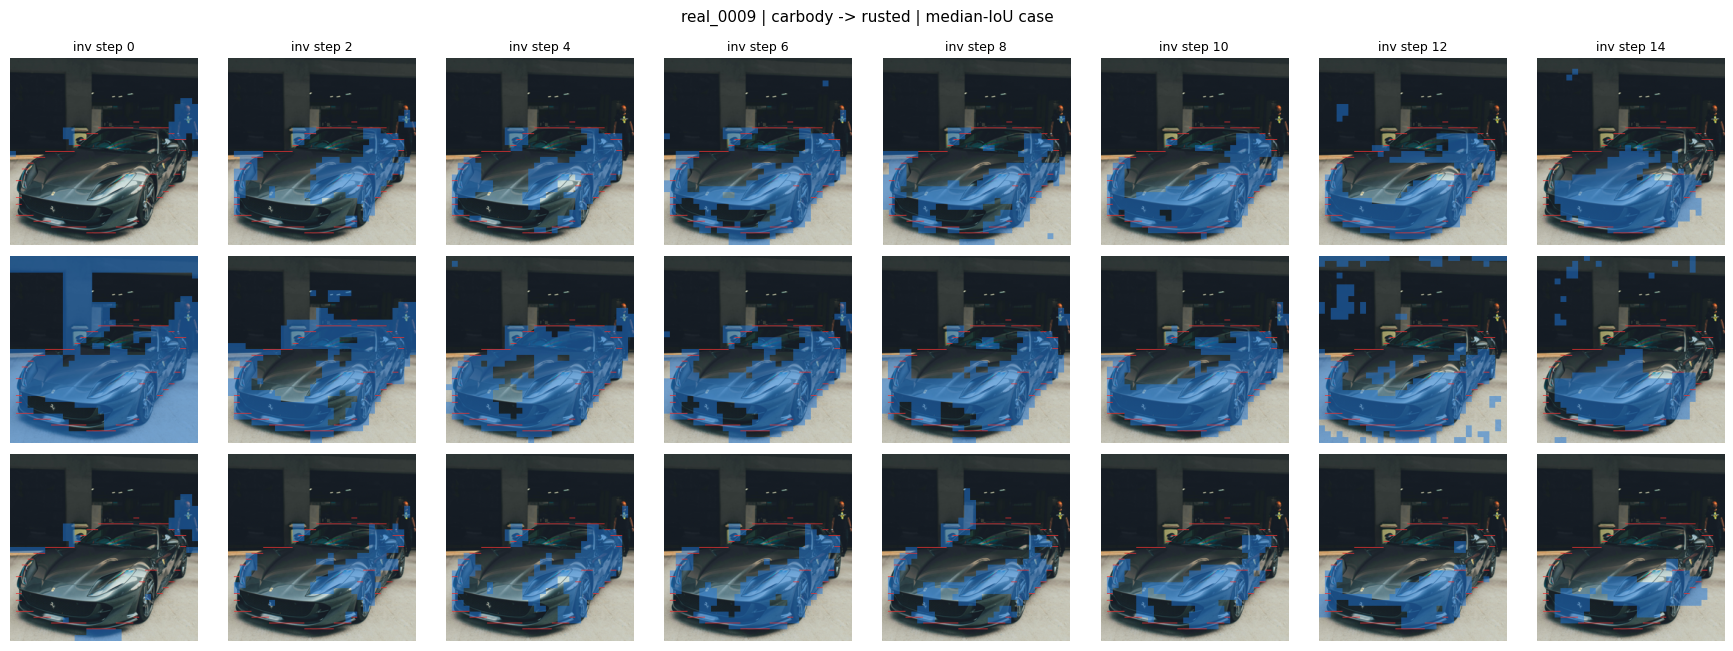

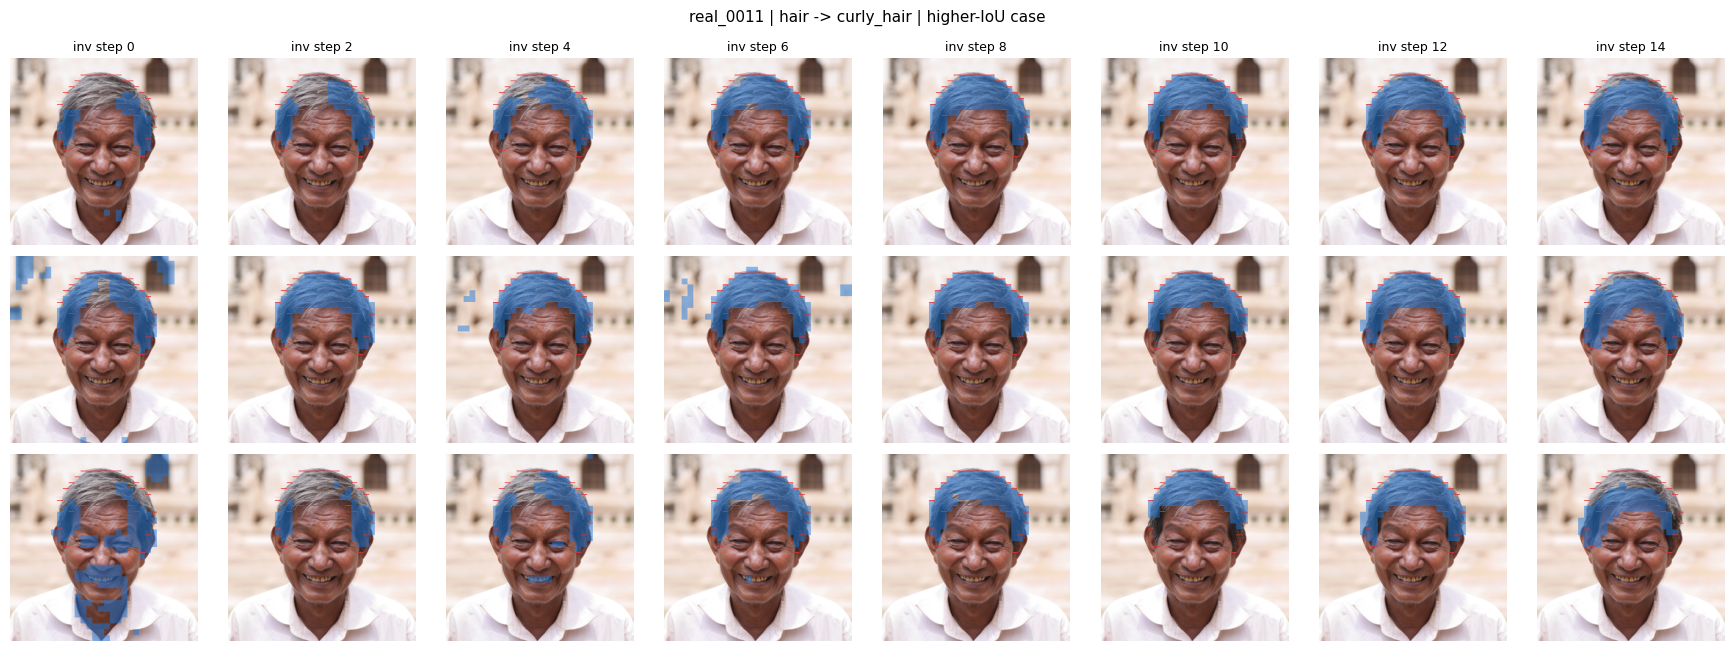

saved:
/Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/inversion_localization_eval/stepwise_masks_real_0006.png
/Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/inversion_localization_eval/stepwise_masks_real_0009.png
/Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/inversion_localization_eval/stepwise_masks_real_0011.png


In [10]:
# Show the binary mask at several inversion steps for fixed representative cases.
step_columns = [0, 2, 4, 6, 8, 10, 12, 14]
step_columns = [step for step in step_columns if step in next(iter(cache.values()))["steps"]]

def draw_binary_overlay(source_path, mask, gt, color=(30, 120, 220), alpha=.50):
    base = np.asarray(Image.open(source_path).convert("RGB").resize((256, 256))) / 255.0
    mask_img = Image.fromarray((np.asarray(mask, dtype=np.uint8) * 255)).resize((256, 256), Image.Resampling.NEAREST)
    mask_arr = np.asarray(mask_img) > 0
    canvas = base.copy()
    tint = np.asarray(color) / 255.0
    canvas[mask_arr] = canvas[mask_arr] * (1 - alpha) + tint * alpha
    gt_img = Image.fromarray((np.asarray(gt, dtype=np.uint8) * 255)).resize((256, 256), Image.Resampling.NEAREST)
    gt_arr = np.asarray(gt_img) > 0
    edge = gt_arr & ~np.roll(gt_arr, 1, axis=0) | gt_arr & ~np.roll(gt_arr, -1, axis=0)
    canvas[edge] = np.asarray((230, 50, 50)) / 255.0
    return canvas

stepwise_paths = []
for uid in representative_uids:
    item = cache[uid]
    source_path = REPO_ROOT / item["record"]["source_image"]
    fig, axes = plt.subplots(3, len(step_columns), figsize=(2.2 * len(step_columns), 6.6), squeeze=False)
    signal_order = ["part_attention", "part_edit_attention", "gate_attention"]
    signal_labels = ["part attention", "part+edit attention", "gate attention"]
    for row_index, (signal_name, signal_label) in enumerate(zip(signal_order, signal_labels)):
        maps = item["signals"][signal_name]
        for col_index, step in enumerate(step_columns):
            step_index = item["steps"].index(step)
            score = maps[step_index]
            smooth = gaussian_filter(normalize01(score), sigma=SMOOTHING_SIGMA)
            binary = smooth > otsu_threshold(smooth)
            axes[row_index, col_index].imshow(draw_binary_overlay(source_path, binary, item["gt"]))
            axes[row_index, col_index].axis("off")
            if row_index == 0:
                axes[row_index, col_index].set_title(f"inv step {step}", fontsize=9)
        axes[row_index, 0].set_ylabel(signal_label, fontsize=9)
    fig.suptitle(f"{uid} | {item['record']['part']} -> {item['record']['edit']} | {representative_labels[uid]}", fontsize=11)
    fig.tight_layout()
    path = OUT_ROOT / f"stepwise_masks_{uid}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    stepwise_paths.append(path)
print("saved:", *stepwise_paths, sep="\n")


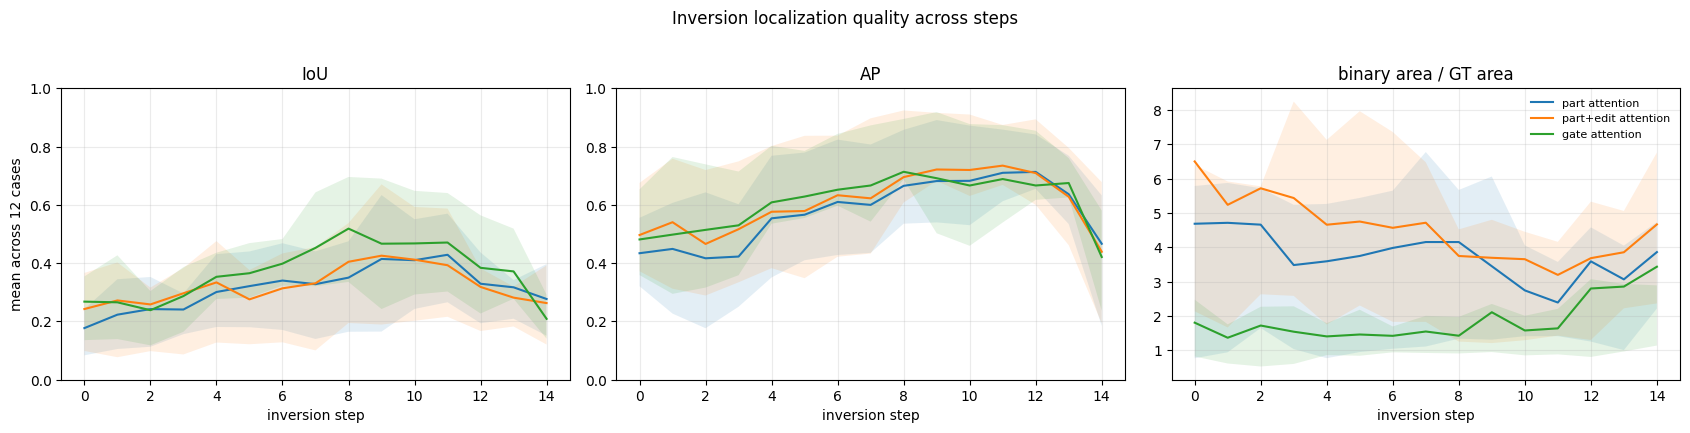

saved: /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/inversion_localization_eval/inversion_step_stability_curves.png


In [11]:
# Plot all-case temporal quality curves.
plot_methods = ["part_attention", "part_edit_attention", "gate_attention"]
plot_labels = {"part_attention": "part attention", "part_edit_attention": "part+edit attention", "gate_attention": "gate attention"}
plot_metrics = [("iou", "IoU"), ("soft_ap", "AP"), ("area_ratio", "binary area / GT area")]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2), squeeze=False)
axes = axes[0]
for axis, (metric_name, title) in zip(axes, plot_metrics):
    for method in plot_methods:
        subset = per_step_metrics[per_step_metrics["method"] == method].copy()
        grouped = subset.groupby("step")[metric_name]
        stats = grouped.agg(["mean", lambda x: x.quantile(.25), lambda x: x.quantile(.75)]).reset_index()
        stats.columns = ["step", "mean", "q25", "q75"]
        axis.plot(stats["step"], stats["mean"], label=plot_labels[method])
        axis.fill_between(stats["step"], stats["q25"], stats["q75"], alpha=.12)
    axis.set_title(title)
    axis.set_xlabel("inversion step")
    axis.grid(alpha=.25)
    if metric_name == "iou": axis.set_ylim(0, 1)
    if metric_name == "soft_ap": axis.set_ylim(0, 1)
axes[0].set_ylabel("mean across 12 cases")
axes[-1].legend(frameon=False, fontsize=8)
fig.suptitle("Inversion localization quality across steps", y=1.02)
fig.tight_layout()
stability_curve_path = OUT_ROOT / "inversion_step_stability_curves.png"
fig.savefig(stability_curve_path, dpi=160, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)
print("saved:", stability_curve_path)


## 6. Interpretation

The stepwise grids show whether each signal remains spatially coherent as inversion progresses. The all-case curves and adjacent-step IoU quantify whether this behavior is general or isolated. A positive result supports the claim that inversion states contain a usable localization signal; it does not yet establish that the signal is sufficient to control final image editing.